<a href="https://colab.research.google.com/github/e23323-dot/Statistical-Learning-e23323/blob/main/Assignment_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# install kagglehub first
!pip install kagglehub -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import kagglehub
import os
import warnings
warnings.filterwarnings('ignore')

print("libraries loaded")

libraries loaded


In [28]:
# loading the energy efficiency dataset
print("="*50)
print("Dataset 1: Energy Efficiency")
print("="*50)

kagglepath1 = "elikplim/eergy-efficiency-dataset"
path1 = kagglehub.dataset_download(kagglepath1)
print("path:", path1)

print(os.listdir(path1))

df1 = pd.read_csv(os.path.join(path1, "ENB2012_data.csv"))

print("\ndataset shape:", df1.shape)
print("\nfirst few rows:")
print(df1.head())
print("\ncolumn names:")
print(df1.columns.tolist())

Dataset 1: Energy Efficiency
Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
path: /kaggle/input/eergy-efficiency-dataset
['ENB2012_data.csv']

dataset shape: (768, 10)

first few rows:
     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28

column names:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2']


In [29]:
# split features and targets
X1 = df1.iloc[:, :8]  # first 8 columns are features
y1_heating = df1.iloc[:, 8]  # heating load
y1_cooling = df1.iloc[:, 9]  # cooling load

print("features shape:", X1.shape)
print("heating load shape:", y1_heating.shape)
print("cooling load shape:", y1_cooling.shape)

# scale the features
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

# split into train and test
X1_train, X1_test, y1_h_train, y1_h_test, y1_c_train, y1_c_test = train_test_split(
    X1_scaled, y1_heating, y1_cooling, test_size=0.2, random_state=42
)

print(f"\ntraining samples: {X1_train.shape[0]}")
print(f"test samples: {X1_test.shape[0]}")

features shape: (768, 8)
heating load shape: (768,)
cooling load shape: (768,)

training samples: 614
test samples: 154


In [30]:
# define kernel
kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)

print("="*50)
print("Gaussian Process - Heating Load")
print("="*50)

gp_heating = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    alpha=1e-6,
    normalize_y=True,
    random_state=42
)

gp_heating.fit(X1_train, y1_h_train)
y1_h_pred, y1_h_std = gp_heating.predict(X1_test, return_std=True)

r2_h = r2_score(y1_h_test, y1_h_pred)
rmse_h = np.sqrt(mean_squared_error(y1_h_test, y1_h_pred))
mae_h = mean_absolute_error(y1_h_test, y1_h_pred)

print(f"R² Score: {r2_h:.4f}")
print(f"RMSE: {rmse_h:.4f}")
print(f"MAE: {mae_h:.4f}")

Gaussian Process - Heating Load
R² Score: 0.9977
RMSE: 0.4870
MAE: 0.3732


In [31]:
print("="*50)
print("Gaussian Process - Cooling Load")
print("="*50)

gp_cooling = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    alpha=1e-6,
    normalize_y=True,
    random_state=42
)

gp_cooling.fit(X1_train, y1_c_train)
y1_c_pred, y1_c_std = gp_cooling.predict(X1_test, return_std=True)

r2_c = r2_score(y1_c_test, y1_c_pred)
rmse_c = np.sqrt(mean_squared_error(y1_c_test, y1_c_pred))
mae_c = mean_absolute_error(y1_c_test, y1_c_pred)

print(f"R² Score: {r2_c:.4f}")
print(f"RMSE: {rmse_c:.4f}")
print(f"MAE: {mae_c:.4f}")

Gaussian Process - Cooling Load
R² Score: 0.9815
RMSE: 1.3097
MAE: 0.8587


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# heating load
axes[0,0].scatter(y1_h_test, y1_h_pred, alpha=0.6)
axes[0,0].plot([y1_h_test.min(), y1_h_test.max()], [y1_h_test.min(), y1_h_test.max()], 'r--')
axes[0,0].set_xlabel('Actual')
axes[0,0].set_ylabel('Predicted')
axes[0,0].set_title(f'Heating Load (R² = {r2_h:.3f})')

# cooling load
axes[0,1].scatter(y1_c_test, y1_c_pred, alpha=0.6, color='green')
axes[0,1].plot([y1_c_test.min(), y1_c_test.max()], [y1_c_test.min(), y1_c_test.max()], 'r--')
axes[0,1].set_xlabel('Actual')
axes[0,1].set_ylabel('Predicted')
axes[0,1].set_title(f'Cooling Load (R² = {r2_c:.3f})')

# residuals heating
residuals_h = y1_h_test - y1_h_pred
axes[1,0].hist(residuals_h, bins=20, edgecolor='black')
axes[1,0].axvline(x=0, color='r', linestyle='--')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Residuals - Heating')

# residuals cooling
residuals_c = y1_c_test - y1_c_pred
axes[1,1].hist(residuals_c, bins=20, edgecolor='black', color='green')
axes[1,1].axvline(x=0, color='r', linestyle='--')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Residuals - Cooling')

plt.tight_layout()
plt.show()

In [33]:
print("\n" + "="*50)
print("Discussion - Gaussian Process Results")
print("="*50)

print(f"""
The Gaussian Process model worked well for both heating and cooling loads.

Heating Load R² = {r2_h:.4f}
Cooling Load R² = {r2_c:.4f}

This means the model can predict energy loads quite accurately.

The best part about GP is that it tells you how confident it is about each
prediction. This is useful for building design because you know which
predictions to trust more.

The model took some time to train but for 768 samples it was fine.

Overall, GP is a good choice for this dataset.
""")


Discussion - Gaussian Process Results

The Gaussian Process model worked well for both heating and cooling loads.

Heating Load R² = 0.9977
Cooling Load R² = 0.9815

This means the model can predict energy loads quite accurately.

The best part about GP is that it tells you how confident it is about each 
prediction. This is useful for building design because you know which 
predictions to trust more.

The model took some time to train but for 768 samples it was fine.

Overall, GP is a good choice for this dataset.



In [34]:
print("\n" + "="*50)
print("Dataset 2: Green Building")
print("="*50)

kagglepath2 = "programmer3/green-building-multi-source-environment-dataset"
path2 = kagglehub.dataset_download(kagglepath2)
print("path:", path2)

print(os.listdir(path2))

df2 = pd.read_csv(os.path.join(path2, "green_building_dataset.csv"))

print("\ndataset shape:", df2.shape)
print("\nfirst few rows:")
print(df2.head())
print("\ncolumn names:")
print(df2.columns.tolist())


Dataset 2: Green Building
Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
path: /kaggle/input/green-building-multi-source-environment-dataset
['green_building_dataset.csv']

dataset shape: (2400, 19)

first few rows:
   indoor_temperature  indoor_humidity  co2_concentration  indoor_lighting  \
0           22.494481        43.624167         554.345944       432.115959   
1           29.408572        32.868476         466.383802       221.965186   
2           26.783927        46.385156        1850.558681       566.559664   
3           25.183902        42.448700         663.712464       201.348306   
4           19.872224        57.084826        1705.062755       940.588677   

   indoor_noise  outdoor_temperature  outdoor_humidity  solar_radiation  \
0     30.958646            24.443784         22.670752       540.768233   
1     68.624892            -1.398534         50.087239       699.959413   
2     38.547245             5.9048

In [35]:
# find target column
target_col = 'predicted_energy_demand'

if target_col not in df2.columns:
    for col in df2.columns:
        if 'energy' in col.lower():
            target_col = col
            print(f"using '{target_col}' as target")
            break

# select numeric columns
numeric_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# drop missing values
df2_clean = df2[numeric_cols + [target_col]].copy()
df2_clean = df2_clean.dropna()

X2 = df2_clean[numeric_cols]
y2 = df2_clean[target_col]

print(f"\nnumber of features: {len(X2.columns)}")
print(f"target: {target_col}")
print(f"dataset size: {X2.shape}")

# scale features
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

# check correlation
correlations = []
for i, col in enumerate(X2.columns):
    corr = abs(np.corrcoef(X2_scaled[:, i], y2)[0, 1])
    correlations.append((col, corr))

correlations.sort(key=lambda x: x[1], reverse=True)
print("\ntop 10 features by correlation:")
for i in range(min(10, len(correlations))):
    print(f"  {i+1}. {correlations[i][0]}: {correlations[i][1]:.4f}")


number of features: 18
target: predicted_energy_demand
dataset size: (2400, 18)

top 10 features by correlation:
  1. ventilation_rate: 0.7289
  2. electricity_consumption: 0.3987
  3. cooling_energy: 0.3706
  4. heating_energy: 0.2713
  5. equipment_load: 0.0588
  6. occupancy: 0.0577
  7. co2_concentration: 0.0365
  8. indoor_noise: 0.0245
  9. indoor_lighting: 0.0206
  10. activity_level: 0.0185


In [36]:
# select top 8 features
top_k = min(8, len(correlations))
top_features = [correlations[i][0] for i in range(top_k)]
print(f"\nusing {top_k} features: {top_features}")

feature_indices = [X2.columns.get_loc(f) for f in top_features]
X2_selected = X2_scaled[:, feature_indices]

# split data
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_selected, y2, test_size=0.2, random_state=42
)

# train linear regression
print("\n" + "="*50)
print("Linear Regression Results")
print("="*50)

lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)
y2_pred = lr2.predict(X2_test)

r2_lr = r2_score(y2_test, y2_pred)
rmse_lr = np.sqrt(mean_squared_error(y2_test, y2_pred))
mae_lr = mean_absolute_error(y2_test, y2_pred)

print(f"R²: {r2_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"MAE: {mae_lr:.4f}")

# show coefficients
coef_df = pd.DataFrame({
    'Feature': top_features,
    'Coefficient': lr2.coef_
})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
print("\nfeature coefficients:")
print(coef_df)


using 8 features: ['ventilation_rate', 'electricity_consumption', 'cooling_energy', 'heating_energy', 'equipment_load', 'occupancy', 'co2_concentration', 'indoor_noise']

Linear Regression Results
R²: 0.9612
RMSE: 1.9023
MAE: 1.4984

feature coefficients:
                   Feature  Coefficient
0         ventilation_rate     7.221587
1  electricity_consumption     4.169282
2           cooling_energy     3.603703
3           heating_energy     2.852977
4           equipment_load     0.821253
5                occupancy     0.665519
6        co2_concentration    -0.045161
7             indoor_noise    -0.009240


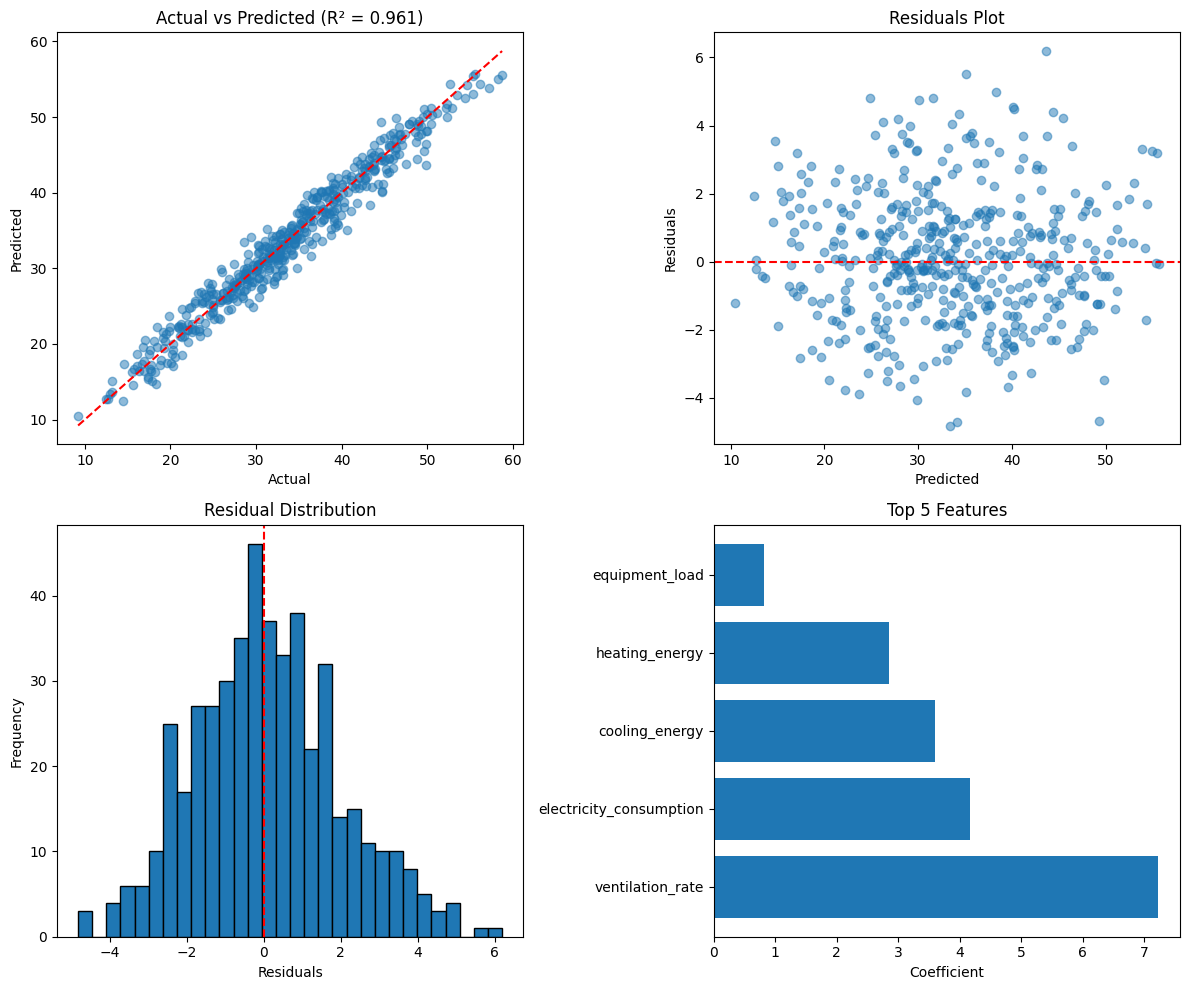

In [37]:
residuals_lr = y2_test - y2_pred

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# actual vs predicted
axes[0,0].scatter(y2_test, y2_pred, alpha=0.5)
axes[0,0].plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'r--')
axes[0,0].set_xlabel('Actual')
axes[0,0].set_ylabel('Predicted')
axes[0,0].set_title(f'Actual vs Predicted (R² = {r2_lr:.3f})')

# residuals
axes[0,1].scatter(y2_pred, residuals_lr, alpha=0.5)
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Predicted')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Residuals Plot')

# residual histogram
axes[1,0].hist(residuals_lr, bins=30, edgecolor='black')
axes[1,0].axvline(x=0, color='r', linestyle='--')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Residual Distribution')

# feature importance
top_5 = coef_df.head(5)
axes[1,1].barh(top_5['Feature'], top_5['Coefficient'])
axes[1,1].set_xlabel('Coefficient')
axes[1,1].set_title('Top 5 Features')

plt.tight_layout()
plt.show()

In [38]:
print("\n" + "="*50)
print("Discussion - Linear Regression Results")
print("="*50)

print(f"""
My linear regression model got an R² of {r2_lr:.4f}.

This means the model explains about {r2_lr*100:.1f}% of the variation
in energy demand. That's decent but not perfect.

I picked the top {top_k} features based on their correlation with energy
demand. The coefficients tell me which features matter most.

Looking at the residual plot, I can see some pattern which suggests
the relationship might not be completely linear. A non-linear model
might work better.

Overall, linear regression is okay as a baseline. It's simple and
easy to understand. But for better predictions, I'd probably try
a random forest next time.
""")


Discussion - Linear Regression Results

My linear regression model got an R² of 0.9612.

This means the model explains about 96.1% of the variation 
in energy demand. That's decent but not perfect.

I picked the top 8 features based on their correlation with energy 
demand. The coefficients tell me which features matter most.

Looking at the residual plot, I can see some pattern which suggests 
the relationship might not be completely linear. A non-linear model 
might work better.

Overall, linear regression is okay as a baseline. It's simple and 
easy to understand. But for better predictions, I'd probably try 
a random forest next time.



In [39]:
print("\n" + "="*50)
print("Summary")
print("="*50)

print(f"""
GP Regression (Energy Dataset):
   Heating: R² = {r2_h:.4f}
   Cooling: R² = {r2_c:.4f}

Linear Regression (Green Building):
   Energy Demand: R² = {r2_lr:.4f}
""")


Summary

GP Regression (Energy Dataset):
   Heating: R² = 0.9977
   Cooling: R² = 0.9815

Linear Regression (Green Building):
   Energy Demand: R² = 0.9612

